# Erkennen von Zeichensprachen Ziffern

In dieser Übung arbeiten wir mit einem Datensatz von Zeichensprachen Zeichen (in Bildform) für die Ziffern von 0 bis 9: [Datensatz](https://github.com/ardamavi/Sign-Language-Digits-Dataset)

Wir werden hier logistische Regression mit soft-max (da für jedes Bild nur genau eine Ziffer korrekt sein kann) verwenden, um die Vorhersage zu generieren. Für Bilddaten ist logistische Regression im allgemeinen nicht das Mittel der Wahl - aber dadurch können wir recht deutlich den Effekt von Overfitting hier beobachten.

## Daten laden

Als erstes müssen Sie die Daten laden. Es gibt insgesamt 10 Unterordner mit mehreren JPG Dateien. Um über alle Dateien zu iterieren können Sie das Package `glob` verwenden. `for filename in glob.glob("Dataset/3/*.JPG"):` liefert alle Dateien, die zum Label "3" gehören.

Eine einzelne JPG Datei können Sie mit `cv2.imread(filename)` einlesen. Das Ergebnis ist ein Numpy Array mit shape `(100, 100, 3)`, der ein Bild repräsentiert. Jeder Eintrag ist eine Zahl zwischen 0 und 255.

Füge alle Daten zu einem Numpy Array `X` mit Shape `X.shape == (2062,100,100,3)` und einem Array `Y` mit den Labeln von 0 bis 9 mit Shape `Y.shape == (2062,)` zusammen.

Achtung: Es gibt Bilder, die nicht die 100x100 Standardgröße haben. Diese können Sie mit `cv2.resize(image, (100, 100))` auf das Einheitsformat skalieren.


In [7]:
import glob
import cv2
import numpy as np

# ADD CODE HERE
X = []
Y = []

for label in range(0,10):
    directory = glob.glob(f"Dataset/{label}/*.JPG")
    for image_name in directory:
        image = cv2.imread(image_name)
        if image is not None:
            X.append(cv2.resize(image, (100, 100)))
            Y.append(label)


## Beispiele inspizieren

Hier Können Sie sich Beispiel Bilder anschauen.

0


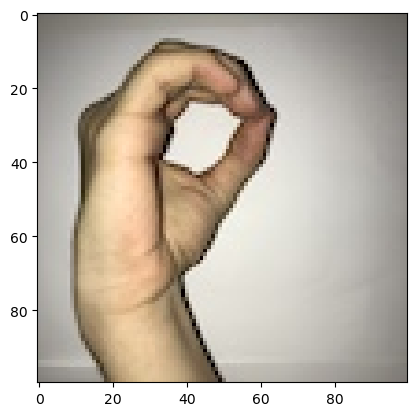

In [8]:
import matplotlib.pyplot as plt

print(Y[0])
plt.imshow(cv2.cvtColor(X[0], cv2.COLOR_BGR2RGB))

## Train-Test Split

Wir teilen hier die Daten nach Trainings und Testdaten auf. Diese Aufteilung lassen wir für den Rest des Notebooks fix. Die Testdaten verwenden wir nur, um die Modelle auszuwerten, nicht um später die Hyperparameter einzustellen.

Verwenden Siesklearn.model_selection.train_test_split` um die Daten aufzuteilen. Wir wollen 20% der Daten für das Testset zurückhalten. Mit dem Parameter `shuffle=True` können wir die Beispiele durchmischen (damit nicht alle Beispiele mit gleichem Label hintereinander kommen). Mit `random_state=1` können wir dafür sorgen, dass der Zufallsgenerator bei allen den gleichen Split erzeugt.

In [12]:
from sklearn.model_selection import train_test_split

# ADD CODE HERE
features_train, features_test, target_train, target_test = train_test_split(X, Y, test_size=0.2, shuffle= True, random_state=1)

## Logistische Regression mit und ohne Regularisierung

Jetzt wollen wir einmal testen, wie gut Logistische Regression mit und ohne Regularisierung für dieses Problem funktioniert.
Durch den Parameter `penalty="none"` kann die Regularisierung ausgeschaltet werden. Trainieren Sie je eine logistische Regression mit "l2" Regularisierung (default) und ohne.

Wir müssen daran denken, dass die Daten noch in die richtige Form gebracht werden müssen. Durch die Numpy Operation `reshape` können wir jedes Bild in einen langen Vektor (mit 30000 Einträgen) verwandeln. Es ergibt auch Sinn, alle Einträge durch 255 zu teilen, um die Werte auf den Bereich 0 bis 1 zu skalieren.

Dieses Beispiel ist schon recht groß und es dauert einige Zeit, um die richtigen Parameter zu finden. Im Default, hat der Optimizer nicht genug Iterationen um zu konvergieren. Mit dem Parameter `max_iter=10000` geben wir ihm mehr Zeit.

Fitten Sie die 2 Modelle und Vergleichen Sie die Accuracy auf dem Trainings- und dem Test-Set

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ADD CODE HERE

models = {'L2 Reg':LogisticRegression(max_iter=1000), 'No Reg': LogisticRegression(max_iter=1000, penalty= None)}

#regression nimmt matrix sample, feature entgegen, daher muss 3d array in eine Liste von Pixeln umgewandelt werden
def norm(mdm_arr):
    mdm_arr= np.array(mdm_arr)
    mdm_arr = mdm_arr.reshape(len(mdm_arr), 30000) #länge insgesamt, länge des eintrages
    #scaling
    return mdm_arr/255

features_train_norm = norm(features_train)
features_test_norm = norm(features_test)

#fit

for name, model in models.items():
    print(f"Model {name}:")
    print("fit started")
    model.fit(features_train_norm, target_train)
    print("predictions")
    predictions_train = model.predict(features_train_norm)
    predictions_test = model.predict(features_test_norm)
    print(f"Train acc:\n{accuracy_score(target_train, predictions_train)}\n")
    print(f"Test acc:\n{accuracy_score(target_test, predictions_test)}\n")





Model L2 Reg:
fit started
predictions
Train acc:
1.0

Test acc:
0.7675544794188862

Model No Reg:
fit started
predictions
Train acc:
1.0

Test acc:
0.774818401937046



## Feintuning

Wir sehen, dass unser Modell ordentlich Overfitted (ohne Regularisierung noch mehr als mit). Wir wollen jetzt schauen, wie wir zu einem möglichst guten Modell kommen.
Wir wollen folgende Stellschrauben ausprobieren:

- Bilder skalieren: Wir können die Größe des Bildes verringern (auf 16x16, 32x32 oder 64x64)
- Graustufen: Wir können über die Farbkanäle mitteln um ein Graustufenbild zu erhalten und so die Anzahl Features reduzieren
- Regularisierung: Wir können ohne Regularisierung und mit L2 Regularisierung rechnen. Mit L2 Regularisierung können wir die Stärke der Regularisierung über den Paramter `C>0` steuern (In scikit-learn ist dies so eingestellt, dass ein kleineres C mehr Regularisierung entspricht). Die Werte für C, die wir ausprobieren wollen sind 0.125, 0.25, 0.5, 1.0 und 1.5.

Wir wollen alle diese möglichen Settings in allen Kombinationen austesten und per k-fold Cross Validation testen.
Es ist sinnvoll, eine Methode `transform_data(X, grayscale, im_size)` zu implementieren, welche die Transformation der Input Daten erledigt. Die Bildgröße können wir, wie zuvor, mit `cv2.resize` modifizieren.

Mit `cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)` kann ein Bild in Graustufen konvertiert werden.

Auch hier müssen wir natürlich wieder die Bilder in flache Vektoren resizen und durch 255 teilen um in der Range 0 bis 1 zu landen.

In [9]:
def transform_data(X, grayscale, im_size):
    
    X_transformed = []
    
    for image_idx in range(len(X)):
        img = cv2.resize(X[image_idx], (im_size,im_size))
        if grayscale:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        X_transformed.append(img)
    
    X_transformed = np.array(X_transformed)
    X_transformed = X_transformed.reshape(len(X_transformed), -1) #-1 berechnet length des eintrages automatisch
    return X_transformed/255


Mit `sklearn.model_selection.cross_val_score` kann man recht einfach ein Modell mit k-fold Cross Validation testen. Dabei gibt man den Classifier und die Trainingsdaten mit und gibt die Anzahl der zu berechnenden Folds an. Als Ergebnis bekommt man (im default) den Accuracy Score jedes Folds zurück. Testen Sie das nun für ein beliebiges Setting aus und berechnen Sie den Durchschnittlichen Score über 5 Folds.

In [11]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# ADD CODE HERE
X_transformed = transform_data(X, grayscale=True, im_size=(32))

model = LogisticRegression(max_iter=1000, C=0.125)

scores = cross_val_score(model, X_transformed, Y, cv=5)

print(scores)
print("avg acc: ", np.mean(scores))


[0.75302663 0.76997579 0.74029126 0.76213592 0.74029126]
avg acc:  0.7531441735818896


Nun haben wir alle Bauteile zusammen. Berechnen Sie den durschnittlichen Score von 5-fold Cross Validation über alle Kombinationen unsere zu testenden Settings.

Achtung, das ist ein recht rechenaufwendiges Unterfangen. Um Unterwegs keine Daten zu verlieren, macht es Sinn, alle Zwischenergebnisse zu speichern. Mit `with open("results.csv", "w") as f:` können Sie eine Datei aufmachen, in der Sie mit `f.write("....\n")` speichern können, für welche Settings du welchen Validation Score erhalten hast. Nach dem write sollten Sie direkt `f.flush()` aufrufen, damit die Daten auch sicher geschrieben werden und nicht nur in einem Buffer landen. Sie können so eine CSV Datei erstellen, wo eine Spalte je Hyperparameter und eine für den Score existiert.

Dann können Sie das Notebook einfach laufen lassen und später mit den Ergebnissen weitermachen. Das Notebook sollte weiterlaufen können, auch wenn Sie das Browserfenster schließen.Sie können sich nur nicht wieder mit dem Notebook verbinden - das heißt Sie müssen mit dem CSV weitermachen, wenn es fertig ist.

In [11]:
# ADD CODE HERE
from sklearn.model_selection import KFold

img_sz = [16, 32, 64]
grayscale = [True, False]
c = [0.125, 0.25, 0.5, 1.0, 1.5]



with open("results.csv", "w") as f:
    f.write("image_size,grayscale,C,score\n")
    for image_size in img_sz:
        for gray in grayscale:
            X_transformed = transform_data(X, gray, image_size)

            #without regularization
            model = LogisticRegression(max_iter=1000, penalty= None)
            scores = cross_val_score(model, X_transformed, Y, cv = 5)

            row = f"{image_size},{gray},None,{np.mean(scores)}\n"
            f.write(row)
            f.flush()
            print(row)

            for c_param in c:
                model = LogisticRegression(max_iter=1000, C=c_param)
                scores = cross_val_score(model, X_transformed, Y, cv = 5)
                row = f"{image_size},{gray},{c_param},{np.mean(scores)}\n"
                f.write(row)
                f.flush()
                print(row)


16,True,None,0.6377289075906815

16,True,0.125,0.7017384047579869

16,True,0.25,0.7230882249230117

16,True,0.5,0.7264815816074661

16,True,1.0,0.7289028891135193

16,True,1.5,0.7259879169703096

16,False,None,0.678471520252004

16,False,0.125,0.7390864853428618

16,False,0.25,0.7444215896001317

16,False,0.5,0.7444157126401655

16,False,1.0,0.7356813747384752

16,False,1.5,0.7332659441923881

32,True,None,0.7269611415407038

32,True,0.125,0.7531441735818896

32,True,0.25,0.7555678318719293

32,True,0.5,0.7579950163379487

32,True,1.0,0.7550823949787254

32,True,1.5,0.7526575612966925

32,False,None,0.7463633371729472

32,False,0.125,0.7686652248524882

32,False,0.25,0.7720621077129222

32,False,0.5,0.7735137168245609

32,False,1.0,0.771574320035732

32,False,1.5,0.7706057970333106

64,True,None,0.7371482639460261

64,True,0.125,0.7662345142104892

64,True,0.25,0.7604127976680223

64,True,0.5,0.7560485671971603

64,True,1.0,0.751683161334305

64,True,1.5,0.7516843367262982

64,False,No

## Der finale Classifier

Wir wollen nun den Classifier mit dem besten Validation Score noch einmal auf allen Trainingsdaten trainieren und auswerten, wie gut dieser auf den Testdaten ist.
Suchen Sie aus Ihrem CSV heraus, welche Parameter den Besten Validation Score hatten.

Trainieren Sie dann eine Logistische Regression mit den zugehörigen Parametern.

Anschließend wollen wir jeweils auf dem Trainings und dem Testset folgende Metriken wissen:

- Accuracy (sklearn.metrics.accuracy_score)
- Area under ROC (sklearn.metrics.roc_auc_score)
- F1 Score (sklearn.metrics.f1_score)

Beachten Sie, dass roc_auc_score als Input nicht die Predictions, sondern die predict_proba Scores benötigt.

Beim roc_auc_score Score müssen wir konfigurieren, wie mit den mehreren Klassen umgegangen werden soll. Mit `multi_class="ovr"` können wir einstellen, dass jede Klasse einzeln gegen den Rest verglichen werden soll und anschließend das Mittel gebildet wird (mit `ovo` kann eingestellt werden, dass die Klassen paarweise gegeneinader verglichen werden).

Beim f1_score muss angegeben werden, wie die Werte für die Klassen gemittelt werden sollen. Mit `average="weighted"` wird angegeben, dass die Klassen gemäß der Anzahl an Labeln mit der Klasse gewichtet werden sollen.

In [29]:
# ADD CODE HERE
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

results = pd.read_csv("results.csv")
#results.head()

max_row_id = results["score"].idxmax()
max_row = results.loc[max_row_id] #[[]] wir erhalten so ein df und kein series

grayscale_value = max_row["grayscale"]
image_size_value = max_row["image_size"]
c_value = max_row["C"]

X_transformed_train = transform_data(features_train, grayscale=grayscale_value, im_size=image_size_value)
X_transformed_test = transform_data(features_test, grayscale=grayscale_value, im_size=image_size_value)
model = LogisticRegression(max_iter=1000, C=c_value, random_state=1)
print("training started")
model.fit(X_transformed_train, target_train)
print("training ended")

print("making predictions")
predictions = model.predict(X_transformed_test)
print("predictions done")

print("making proba")
proba = model.predict_proba(X_transformed_test)
print("proba done")


print("calculating metrics")
acc = accuracy_score(target_test, predictions)
#roc curve x.axis: false positive, y.axis: true positive
roc = roc_auc_score(target_test, proba, multi_class="ovr") #ursprunglich binäre klassifikation, daher für multiclass 1 gegen allen anderen
f1 = f1_score(target_test, predictions, average="weighted")

print(f"Model with parameters: {image_size_value}, {grayscale_value}, {c_value} has following metrics:\n")
print(f"acc (Welcher Anteil der Vorhersagen war korrekt?): {acc}")
print(f"roc (Wie gut ordnet das Modell den richtigen Klassen höhere Wahrscheinlichkeiten zu als den falschen?): {roc}")
print(f"f1 (Harmonisches Mottel aus Prescision und Recall, ist für unbalancierte Datensätze wichtig): {f1}")





training started
training ended
making predictions
predictions done
making proba
proba done
calculating metrics
Model with parameters: 64, False, 0.125 has following metrics:

acc (Welcher Anteil der Vorhersagen war korrekt?): 0.7772397094430993
roc (Wie gut ordnet das Modell den richtigen Klassen höhere Wahrscheinlichkeiten zu als den falschen?): 0.9762220930339478
f1 (Harmonisches Mottel aus Prescision und Recall, ist für unbalancierte Datensätze wichtig): 0.7780952634244724


Drucken Sie mit `sklearn.metrics.confusion_matrix` die Confusion Matrix für die Trainings und die Testdaten aus.

In [ ]:
# ADD CODE HERE

from sklearn.metrics import confusion_matrix
print("Confusion Matrix for traindata")
predictions_train = model.predict(X_transformed_train)
c_matrix_train = confusion_matrix(target_train, predictions_train)
print(f"{c_matrix_train}\n")


print("Confusion Matrix for testdata")
c_matrix_test = confusion_matrix(target_test, predictions)
print(c_matrix_test)

#row - true
#column - vorhergesagt

Confusion Matrix for traindata
[[165   0   0   0   0   0   0   0   0   0]
 [  0 162   0   0   0   0   0   0   0   0]
 [  0   0 166   0   0   0   0   0   0   0]
 [  0   0   0 163   0   0   0   1   0   0]
 [  0   0   0   0 165   0   0   0   0   0]
 [  0   0   0   0   0 163   0   0   0   0]
 [  0   1   0   0   0   0 169   0   0   0]
 [  0   0   0   0   0   0   0 164   0   0]
 [  0   0   0   0   0   0   0   0 161   0]
 [  0   0   0   0   0   0   0   0   0 169]]

Confusion Matrix for testdata
[[35  2  0  2  0  0  1  0  0  0]
 [ 0 32  3  1  1  0  0  2  5  0]
 [ 0  3 31  0  1  0  1  3  1  0]
 [ 0  3  2 34  0  2  1  0  0  0]
 [ 0  0  0  0 29  1  4  2  4  2]
 [ 1  0  0  1  1 40  0  0  0  1]
 [ 0  0  6  0  3  0 26  0  2  0]
 [ 0  3  2  0  4  0  1 28  4  0]
 [ 0  2  2  0  0  1  1  0 38  3]
 [ 1  1  0  2  1  0  1  0  1 28]]


Zum Schluss wollen wir uns noch einmal für jedes Label die ROC Kurve plotten. Das kann man mit `sklearn.metrics.RocCurveDisplay.from_predictions` machen.
Der Methode gibt man die korrekten Labels und die Wahrscheinlichkeiten von `predict_proba` für die jeweilige Klasse mit. Mit dem Parameter `pos_label` kann man angeben, welches Label man gerade betrachten will. Achtung: `predict_proba` gibt die Wahrscheinlichkeiten für alle Klassen mit. Wir dürfen aber nur die für die gerade betrachtete Klasse anschauen (den ROC Plot kann man nur für eine Klasse zur Zeit machen).

So wollen wir einen ROC Plot für alle 10 Klassen machen.

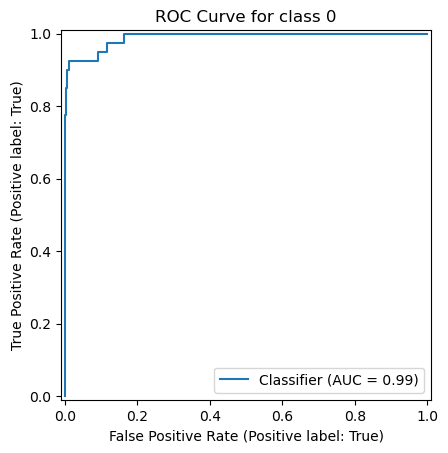

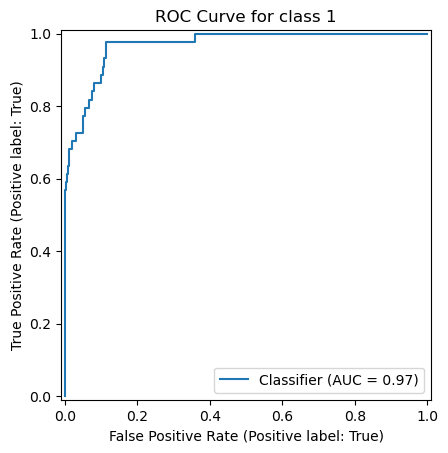

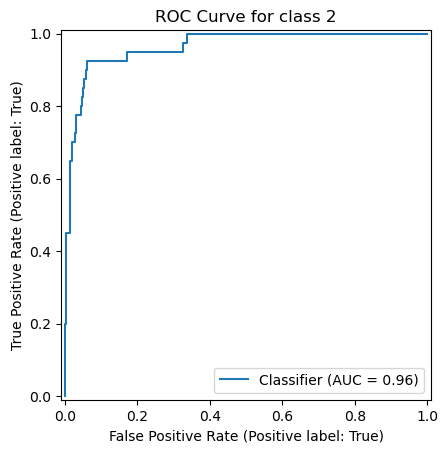

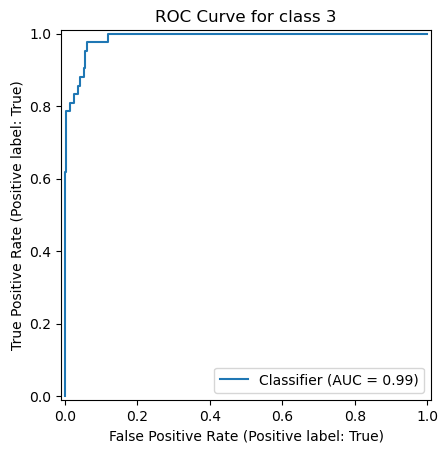

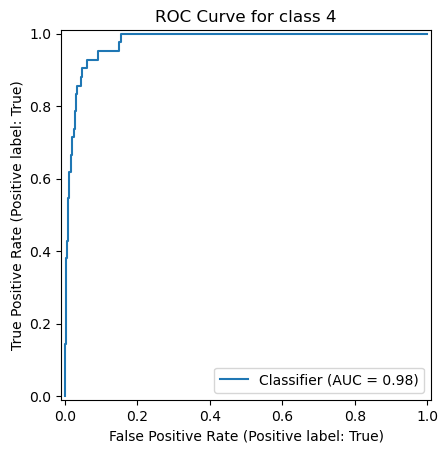

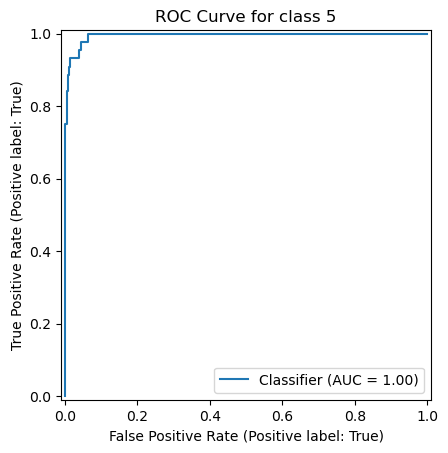

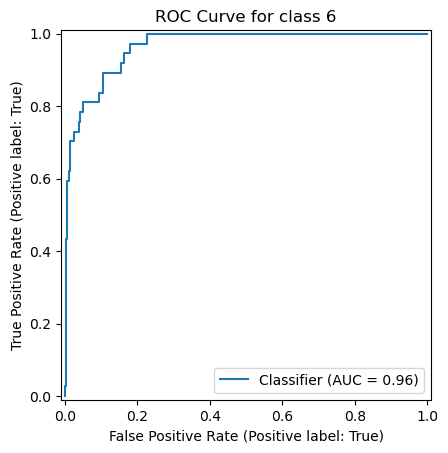

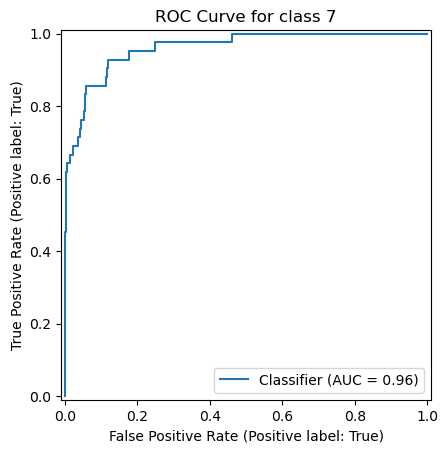

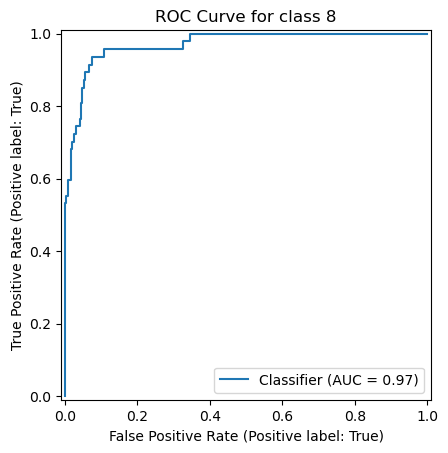

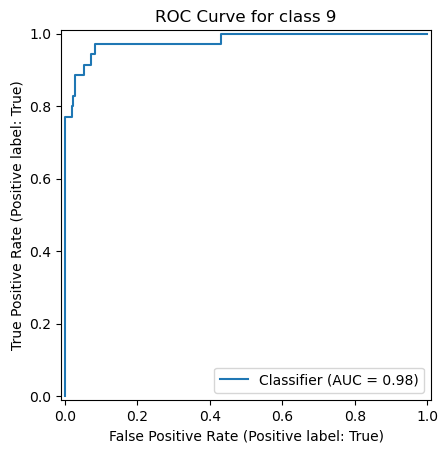

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
# ADD CODE HERE
for class_id in range(10):
    target_np = np.array(target_test)
    target_binary = (target_np == class_id)
    RocCurveDisplay.from_predictions(target_binary, proba[:, class_id], pos_label=True) #class id vs rest | proba[:, class_id] - numpy slicing, alle rows für ein bestimmtes column
    plt.title(f"ROC Curve for class {class_id}")
    plt.show()

#ROC curve zeigt den Tradeoff zwischen TP und FP in Abhängigkeit vom descision treshhold des Modells. z.B wenn treshhold==0.2 -> prob>0.2 -> Positive